# Vedic Text Analysis

This notebook performs a structural analysis of the Vedas (Rigveda, Yajurveda, Atharvaveda). We load the hierarchical JSON data and perform frequency and distribution analysis starting from the lowest levels (Kaanda/Adhyaya) upwards.


In [1]:
import os
import json
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Set up seaborn style
sns.set_theme(style="whitegrid")

# Devanagari Font Setup
font_path = r'C:\Users\admin\AppData\Local\Microsoft\Windows\Fonts\NotoSansDevanagari.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
else:
    print('Devanagari font not found, falling back to sans-serif.')
    plt.rcParams['font.family'] = 'sans-serif'


## 1. Data Loading & Preprocessing

We load the JSON files from the `data/raw/` directory and extract the text grouped by their structural metadata.


In [2]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw')

def clean_and_tokenize(text):
    """Cleans Devanagari text by removing punctuation, dandas, and numbers."""
    if not text:
        return []
    # Remove dandas and numbers
    text = re.sub(r'[\।\॥\0-9०-९]', ' ', text)
    # Remove common English punctuation if any
    text = re.sub(r'[.,;:\-\(\)\[\]\{\}]', ' ', text)
    # Split by whitespace
    words = text.split()
    return words

def load_veda_data(veda_name, dir_name):
    """Loads all JSON files for a given Veda and returns structured data."""
    veda_path = os.path.join(DATA_DIR, dir_name)
    if not os.path.exists(veda_path):
        print(f"Path not found: {veda_path}")
        return []
    
    all_data = []
    for filename in os.listdir(veda_path):
        if filename.endswith('.json'):
            filepath = os.path.join(veda_path, filename)
            with open(filepath, 'r', encoding='utf-8') as f:
                try:
                    data = json.load(f)
                    if isinstance(data, list):
                        for item in data:
                            item['source_file'] = filename
                            all_data.append(item)
                    elif isinstance(data, dict):
                        data['source_file'] = filename
                        all_data.append(data)
                except Exception as e:
                    print(f"Error loading {filename}: {e}")
    return all_data

# Load datasets
atharvaveda_data = load_veda_data('AtharvaVeda', 'AtharvaVeda')
rigveda_data = load_veda_data('Rigveda', 'Rigveda')
yajurveda_data = load_veda_data('Yajurveda', 'Yajurveda')

print(f"Loaded {len(atharvaveda_data)} records for Atharvaveda")
print(f"Loaded {len(rigveda_data)} records for Rigveda")
print(f"Loaded {len(yajurveda_data)} records for Yajurveda")

Loaded 736 records for Atharvaveda
Loaded 1027 records for Rigveda
Loaded 78 records for Yajurveda


## 2. Structural Tokenization

We group the words by their primary structural unit (e.g., `kaanda` for Atharvaveda, `mandala` for Rigveda, `adhyaya` for Yajurveda).


In [3]:
def process_corpus(data_records, struct_key):
    """
    Processes records into a dictionary mapping structural units to Counters of words.
    """
    structure_freqs = defaultdict(Counter)
    global_freq = Counter()
    
    for record in data_records:
        text = record.get('text', '')
        tokens = clean_and_tokenize(text)
        
        # Identify the structural unit identifier
        unit_id = str(record.get(struct_key, record.get('source_file', 'unknown')))
        
        structure_freqs[unit_id].update(tokens)
        global_freq.update(tokens)
        
    return structure_freqs, global_freq

av_struct, av_global = process_corpus(atharvaveda_data, 'kaanda')
rv_struct, rv_global = process_corpus(rigveda_data, 'mandala')
yv_struct, yv_global = process_corpus(yajurveda_data, 'adhyaya')

## 3. High-Frequency Terms per Veda

Let's look at the absolute most common words in each Veda globally.


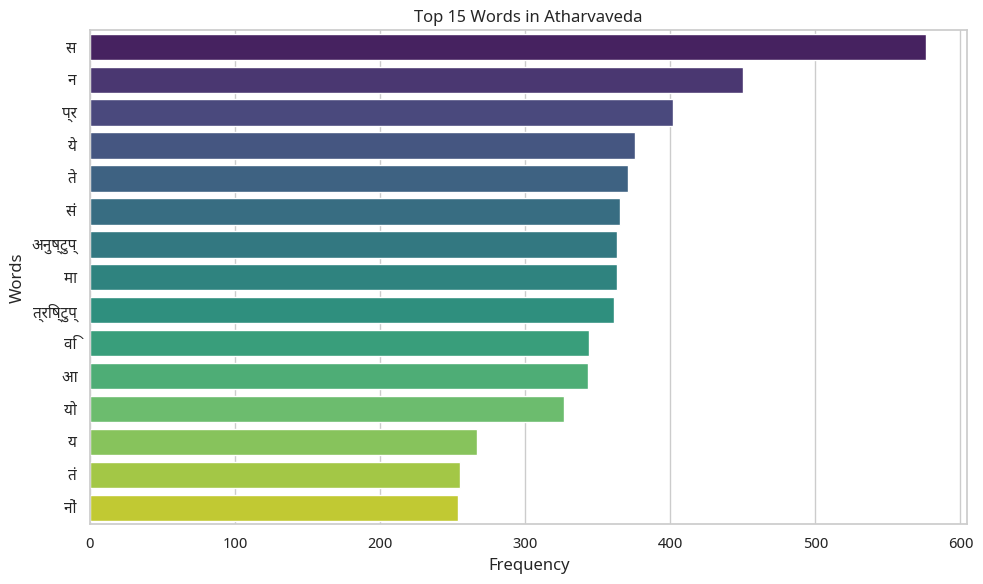

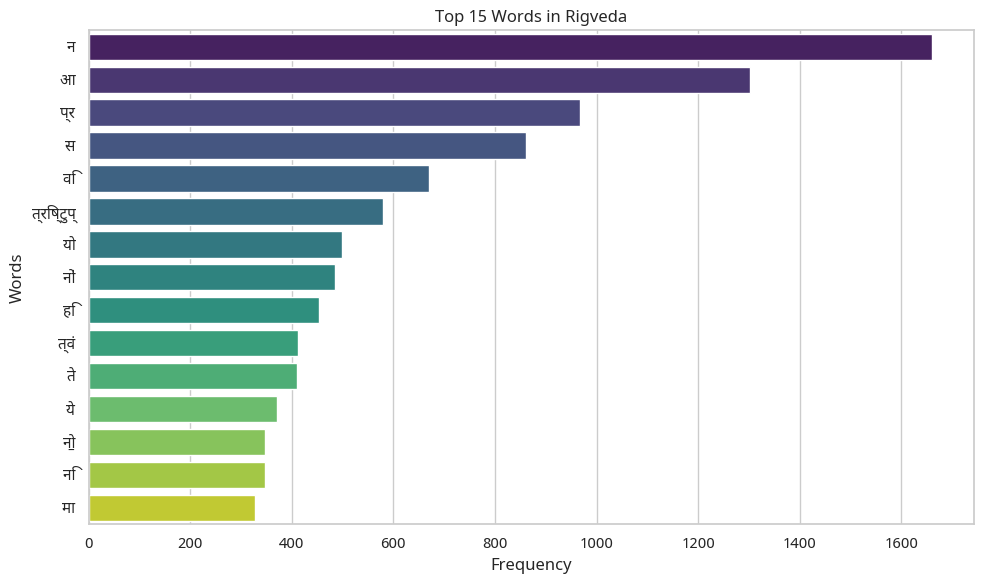

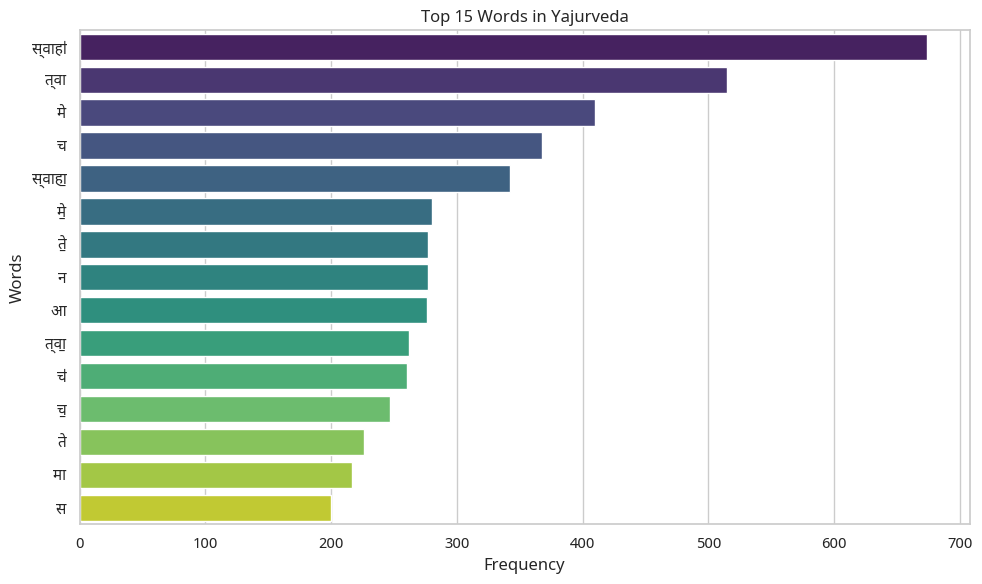

In [4]:
def plot_top_words(freq_counter, title, top_n=15):
    common = freq_counter.most_common(top_n)
    if not common:
        print(f"No words to plot for {title}")
        return
        
    words, counts = zip(*common)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)
    plt.title(f"Top {top_n} Words in {title}")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.tight_layout()
    plt.show()

if av_global:
    plot_top_words(av_global, "Atharvaveda")
if rv_global:
    plot_top_words(rv_global, "Rigveda")
if yv_global:
    plot_top_words(yv_global, "Yajurveda")

## 4. Identifying Unique / Characteristic Terms

Instead of just frequency, let's find words that are extremely common in ONE Veda but relatively rare in others. This highlights domain-specific vocabulary.

We calculate a relative frequency score.


In [5]:
def calculate_relative_frequencies(target_global, other_globals):
    """
    Finds terms that are frequent in 'target' but distinct relative to 'other' compilations.
    """
    target_total = sum(target_global.values())
    if target_total == 0: return []
    
    other_totals = [sum(g.values()) for g in other_globals]
    
    scores = []
    for word, count in target_global.items():
        if count < 10:  # Noise threshold
            continue
            
        target_ratio = count / target_total
        
        other_ratios = []
        for g, total in zip(other_globals, other_totals):
            if total > 0:
                other_ratios.append(g.get(word, 0) / total)
            else:
                other_ratios.append(0)
                
        max_other_ratio = max(other_ratios) if other_ratios else 0
        
        # Simple score: ratio in target vs max ratio in others
        # Add small epsilon to avoid div by zero
        distinction_score = target_ratio / (max_other_ratio + 1e-7)
        
        scores.append((word, count, target_ratio, distinction_score))
        
    # Sort by distinction score
    scores.sort(key=lambda x: x[3], reverse=True)
    return scores

if yv_global:
    print("\n--- Unique/Characteristic Terms in Yajurveda ---")
    yv_unique = calculate_relative_frequencies(yv_global, [av_global, rv_global])
    for word, count, ratio, score in yv_unique[:15]:
        print(f"{word}: Count={count}, Distinction Score={score:.2f}")

if av_global:
    print("\n--- Unique/Characteristic Terms in Atharvaveda ---")
    av_unique = calculate_relative_frequencies(av_global, [yv_global, rv_global])
    for word, count, ratio, score in av_unique[:15]:
        print(f"{word}: Count={count}, Distinction Score={score:.2f}")
    
if rv_global:
    print("\n--- Unique/Characteristic Terms in Rigveda ---")
    rv_unique = calculate_relative_frequencies(rv_global, [av_global, yv_global])
    for word, count, ratio, score in rv_unique[:15]:
        print(f"{word}: Count={count}, Distinction Score={score:.2f}")


--- Unique/Characteristic Terms in Yajurveda ---
होत॒र्यज॑: Count=68, Distinction Score=12128.35
राष्ट्र॒दा: Count=66, Distinction Score=11771.63
वसु॒धेय॑स्य: Count=66, Distinction Score=11771.63
यज॑: Count=66, Distinction Score=11771.63
कल्पन्ताम्: Count=55, Distinction Score=9809.69
पत॑ये॒: Count=50, Distinction Score=8917.90
म॒खाय॑: Count=50, Distinction Score=8917.90
शी॒र्ष्णे: Count=48, Distinction Score=8561.19
योनि॒रिन्द्रा॑य: Count=36, Distinction Score=6420.89
रा॒ष्ट्रम॒मुष्मै॑: Count=34, Distinction Score=6064.17
”: Count=31, Distinction Score=5529.10
उ॒प॒या॒मगृ॑हीतो॒ऽसीन्द्रा॑य: Count=30, Distinction Score=5350.74
उ॒प॒या॒मगृ॑हीतोऽसि: Count=29, Distinction Score=5172.38
दत्त॒: Count=28, Distinction Score=4994.03
“अथ: Count=27, Distinction Score=4815.67

--- Unique/Characteristic Terms in Atharvaveda ---
भुरिक्: Count=130, Distinction Score=16966.63
साम्नी: Count=109, Distinction Score=14225.86
त्रिपदा: Count=102, Distinction Score=13312.28
ब्रह्मा: Count=73, Distinction Scor

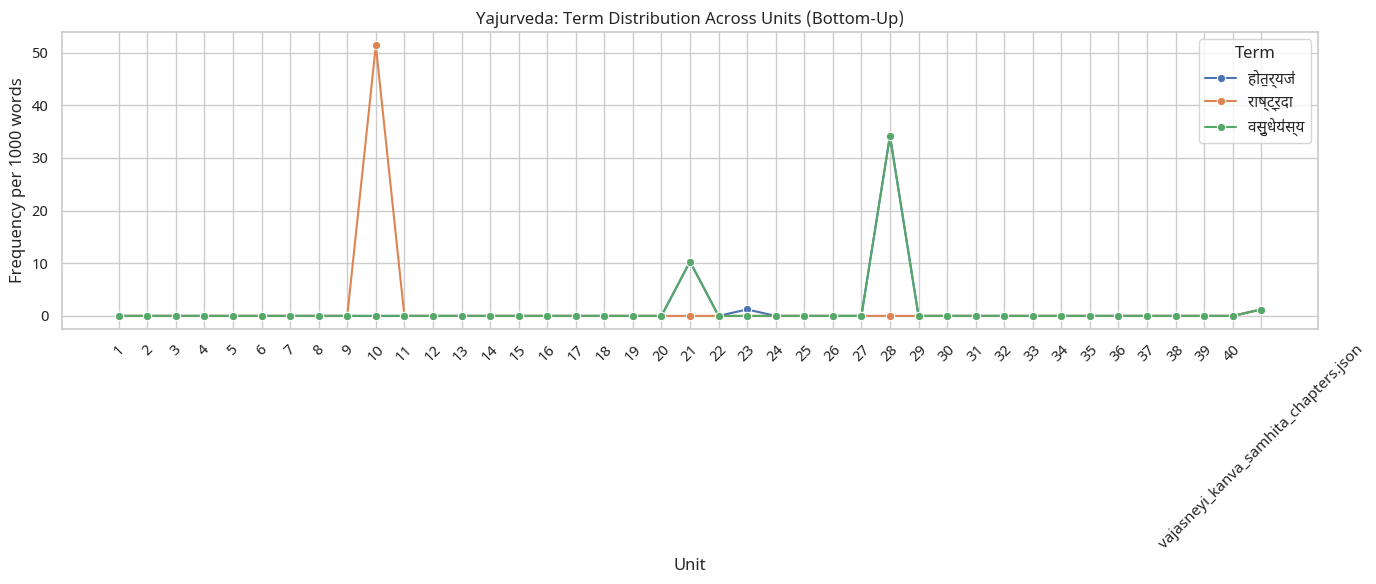

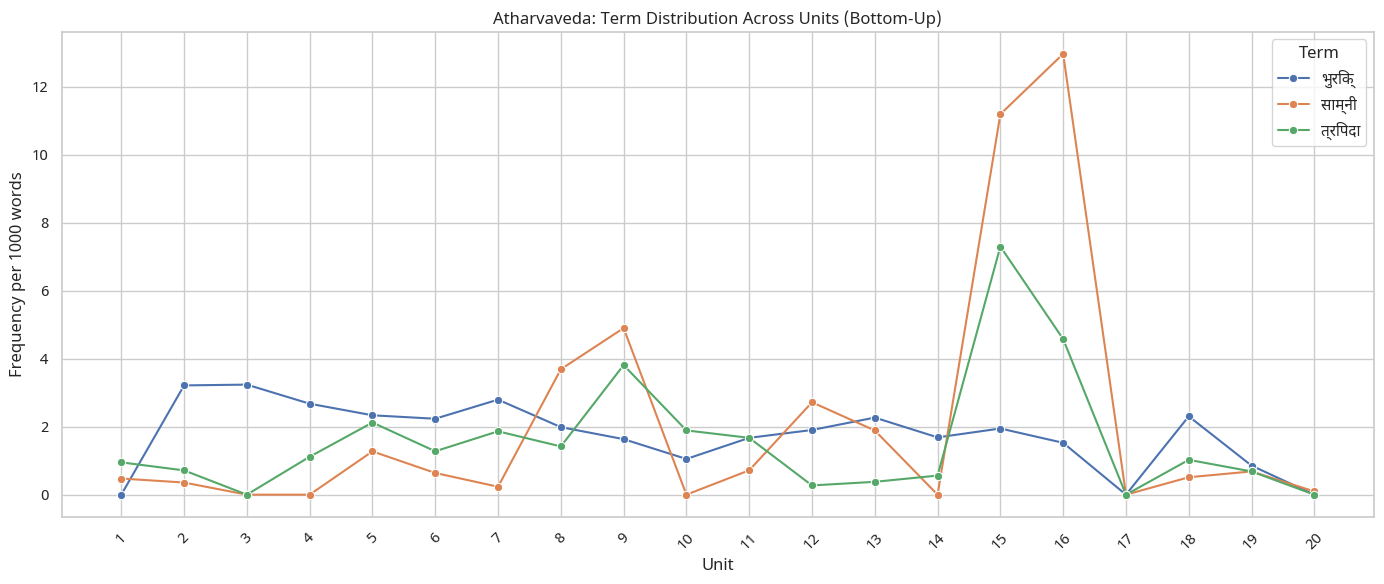

In [6]:
def plot_structural_distribution(struct_data, terms_to_plot, title_prefix):
    if not struct_data or not terms_to_plot:
        return
        
    # Prepare DataFrame
    data = []
    for unit_id, counter in struct_data.items():
        unit_total = sum(counter.values())
        if unit_total == 0: continue
        for term in terms_to_plot:
            count = counter.get(term, 0)
            # Normalized frequency per 1000 words
            norm_freq = (count / unit_total) * 1000
            
            # Try to cast unit_id to int for sorting if possible
            try:
                sort_key = float(re.search(r'\d+', str(unit_id)).group())
            except:
                sort_key = float('inf')
            
            data.append({
                'Unit': str(unit_id),
                'SortKey': sort_key,
                'Term': term,
                'Frequency per 1000 words': norm_freq
            })
            
    df = pd.DataFrame(data)
    if df.empty: return
    
    # Sort by the structural unit
    df = df.sort_values(by=['SortKey', 'Unit'])
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=df, x='Unit', y='Frequency per 1000 words', hue='Term', marker='o')
    plt.title(f"{title_prefix}: Term Distribution Across Units (Bottom-Up)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if yv_global:
    # Example: Plot distribution of top unique terms for Yajurveda
    top_yv_terms = [t[0] for t in yv_unique[:3]]
    plot_structural_distribution(yv_struct, top_yv_terms, "Yajurveda")

if av_global:
    # Example: Plot distribution of top unique terms for Atharvaveda
    top_av_terms = [t[0] for t in av_unique[:3]]
    plot_structural_distribution(av_struct, top_av_terms, "Atharvaveda")

## 6. N-Gram Formulaic Clusters

We port the logic from `pattern_engine.py` to identify the most common 2-gram and 3-gram phrases within each Veda.


In [7]:
def get_top_ngrams(data_records, top_k=10):
    ngram_counter = Counter()
    for record in data_records:
        text = record.get('text', '')
        tokens = clean_and_tokenize(text)
        for n in [2, 3]:
            ngram_counter.update([' '.join(tokens[i:i+n]) for i in range(len(tokens)-n+1)])
    return ngram_counter.most_common(top_k)

if yajurveda_data:
    print("\n--- Top N-Grams in Yajurveda ---")
    for phrase, count in get_top_ngrams(yajurveda_data):
        print(f"{phrase}: {count}")

if atharvaveda_data:
    print("\n--- Top N-Grams in Atharvaveda ---")
    for phrase, count in get_top_ngrams(atharvaveda_data):
        print(f"{phrase}: {count}")

if rigveda_data:
    print("\n--- Top N-Grams in Rigveda ---")
    for phrase, count in get_top_ngrams(rigveda_data):
        print(f"{phrase}: {count}")



--- Top N-Grams in Yajurveda ---
च॑ मे: 65
होत॒र्यज॑ होता॑: 60
ए॒ष ते॒: 54
मे य॒ज्ञेन॑: 54
य॒ज्ञेन॑ कल्पन्ताम्: 54
मे य॒ज्ञेन॑ कल्पन्ताम्: 54
स्थ राष्ट्र॒दा: 50
च मे॒: 50
म॒खाय॑ त्वा: 48
त्वा म॒खस्य॑: 48

--- Top N-Grams in Atharvaveda ---
य ए॒वं: 139
ए॒वं वेद॑: 94
य ए॒वं वेद॑: 94
यं व॒यं: 54
द्वेष्टि॒ यं: 52
द्वेष्टि॒ यं व॒यं: 52
व॒यं द्वि॒ष्मः: 46
यं व॒यं द्वि॒ष्मः: 46
यो॒ स्मान्: 45
स्मान् द्वेष्टि॒: 45

--- Top N-Grams in Rigveda ---
पवमान सोम: 114
पा॑त स्व॒स्तिभि॒: 82
स्व॒स्तिभि॒ सदा॑: 82
सदा॑ नः: 82
पा॑त स्व॒स्तिभि॒ सदा॑: 82
स्व॒स्तिभि॒ सदा॑ नः: 82
जगती त्रिष्टुप्: 77
आ नो॑: 72
इन्द्रः त्रिष्टुप्: 70
सोम गायत्री: 66


C:\Users\admin\AppData\Local\Temp\ipykernel_14460\1332038396.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 57345 (\ue001) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)


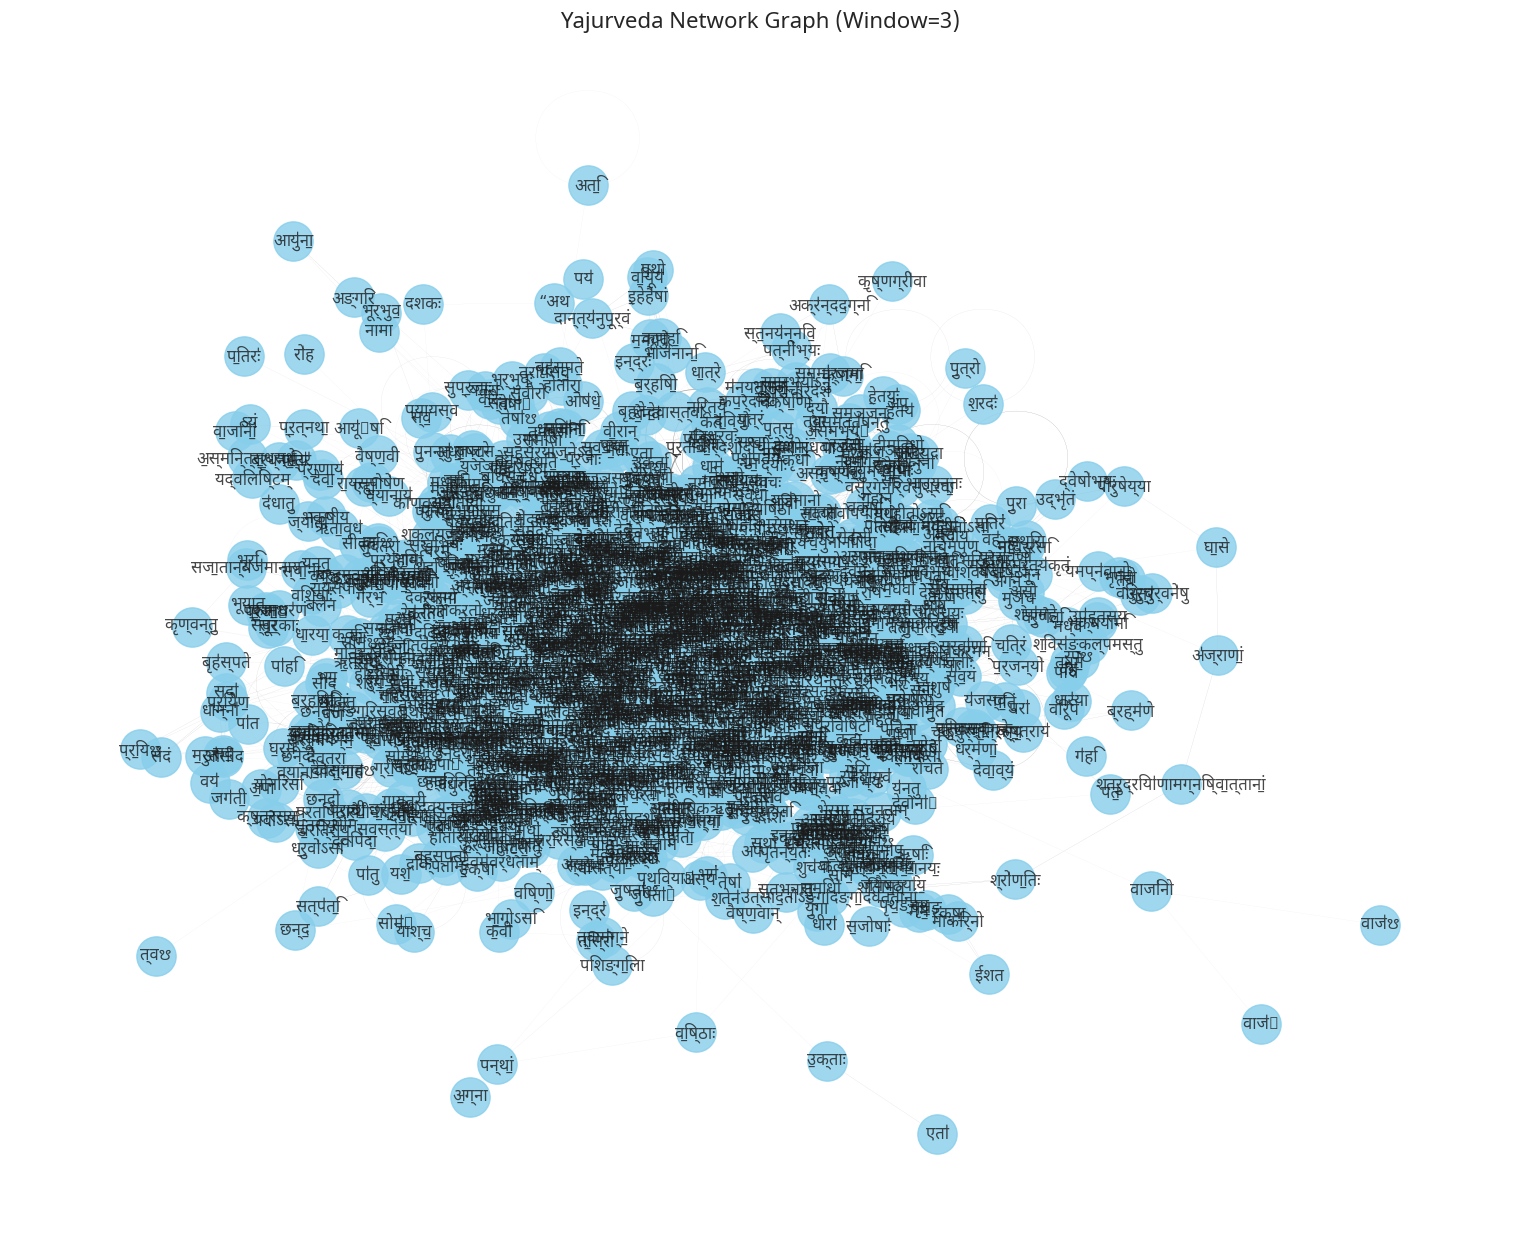

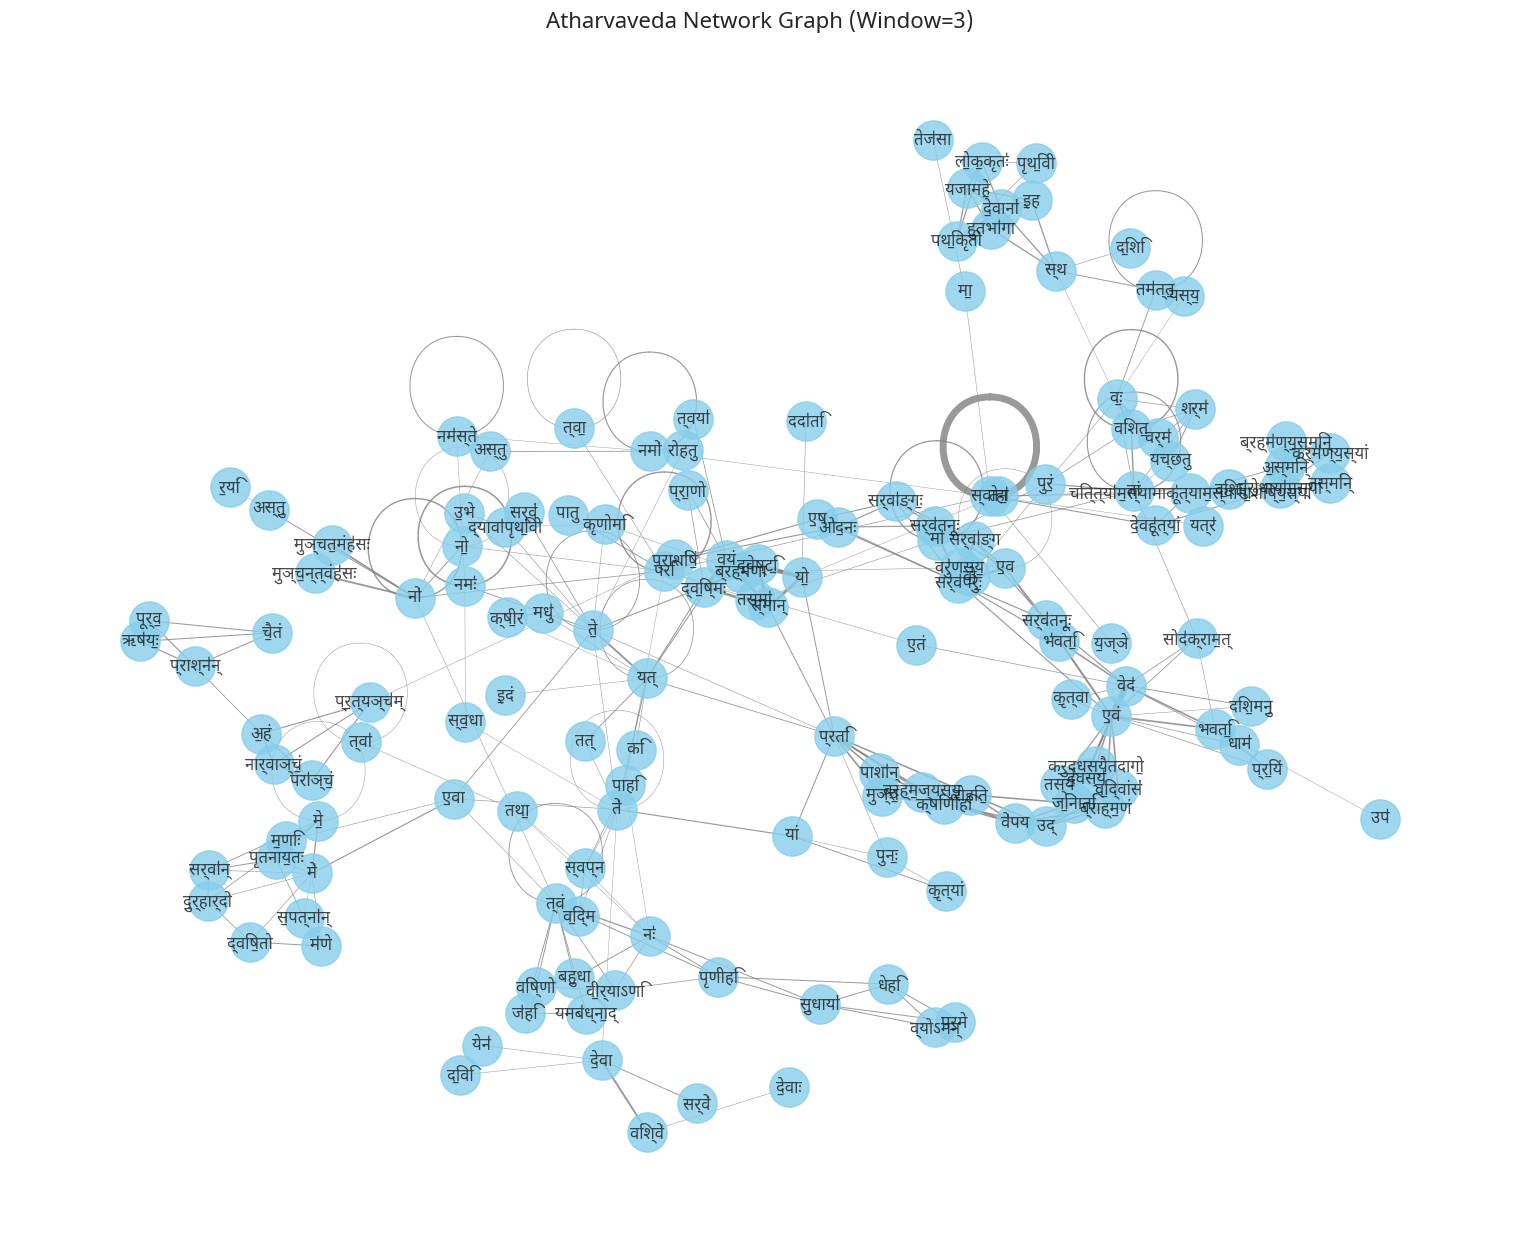

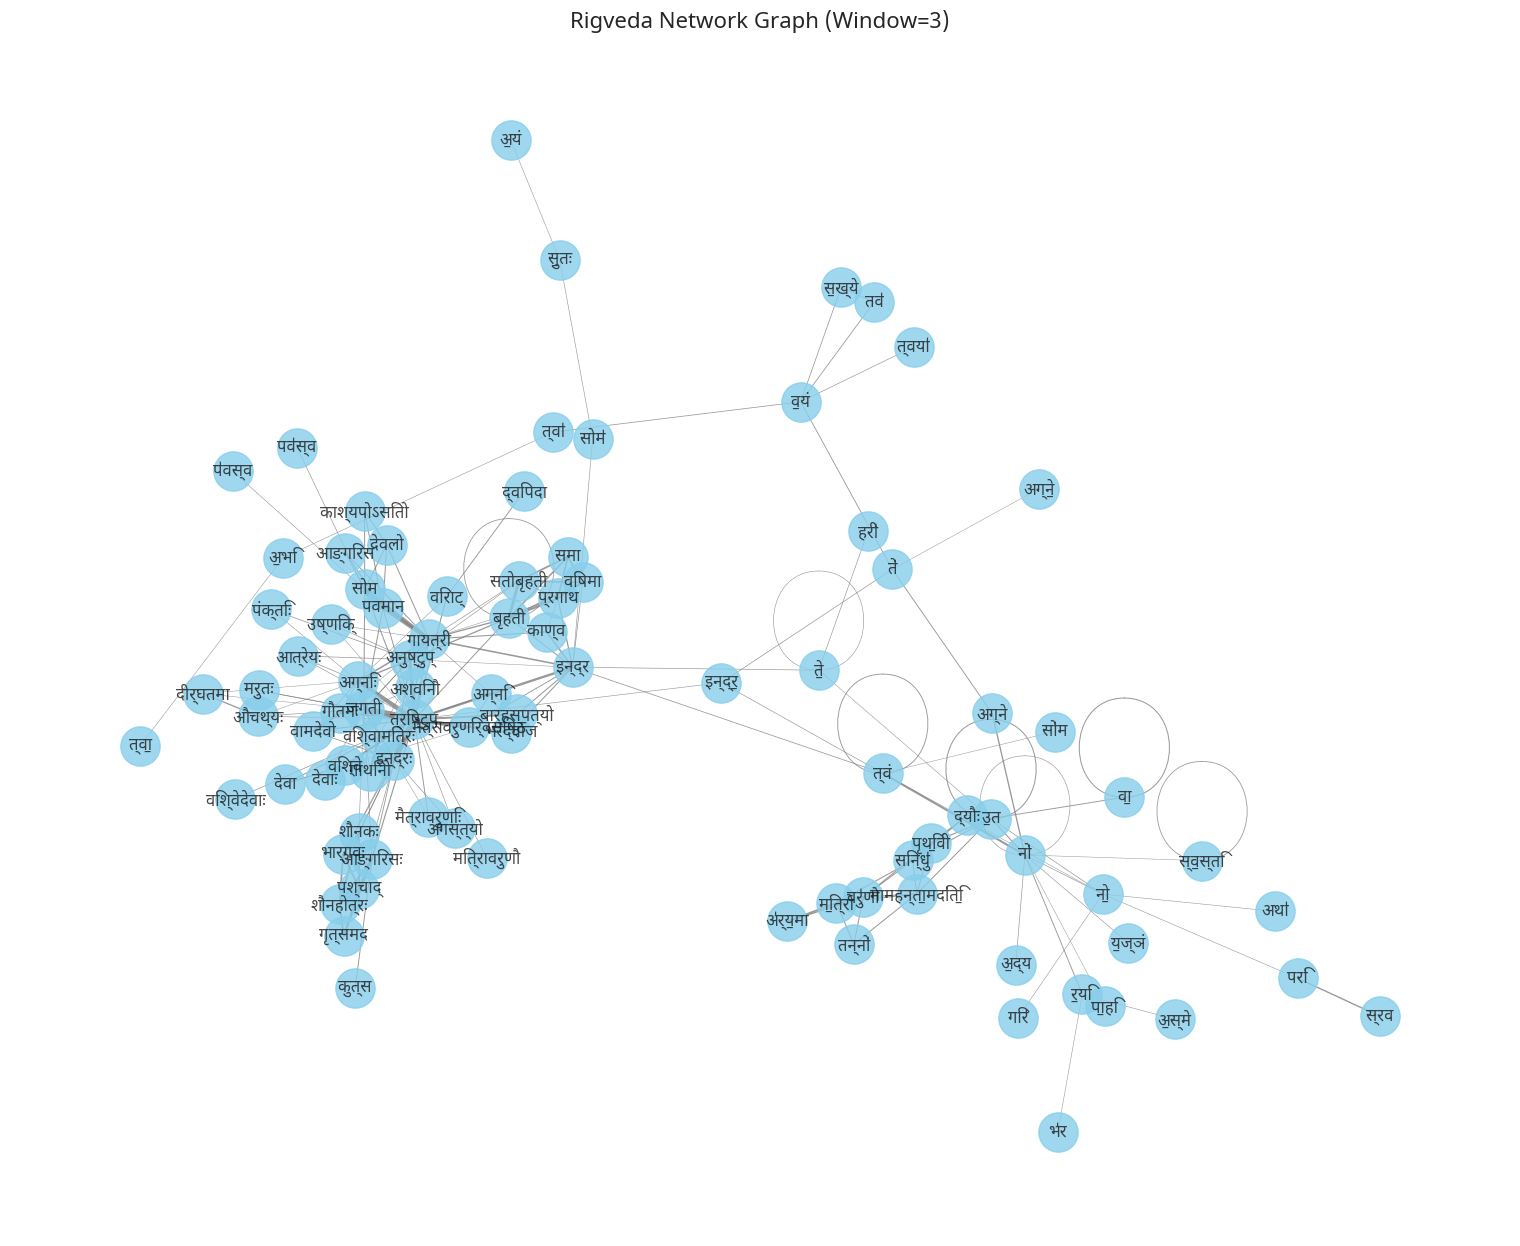

In [8]:
import networkx as nx

def build_collocation_graph(data_records, window_size=3, freq_thresh=5, title="Collocation Graph"):
    co_occurrence = defaultdict(Counter)
    word_freq = Counter()
    
    # Simple stopword list to prevent meaningless structural token connections
    stopwords = {'ते','नो','त्वा','मे','प्र','मा','वि','यो','ये','सं','नः','हि','तं','नि','वा','इति'}
    
    for record in data_records:
        tokens = [w for w in clean_and_tokenize(record.get('text', '')) if w not in stopwords and len(w) > 2]
        word_freq.update(tokens)
        for i, word in enumerate(tokens):
            start = max(0, i - window_size)
            end = min(len(tokens), i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    co_occurrence[word][tokens[j]] += 1

    total_tokens = sum(word_freq.values())
    if total_tokens == 0: return

    G = nx.Graph()
    
    # Filter and construct graph based on co-occurrence threshold
    for w1, neighbors in co_occurrence.items():
        if word_freq[w1] < freq_thresh: continue
        for w2, count in neighbors.items():
            if word_freq[w2] < freq_thresh: continue
            if count < max(2, freq_thresh // 2): continue
            G.add_edge(w1, w2, weight=count)

    if G.number_of_nodes() == 0:
        print(f"No dense clusters found for {title}")
        return
        
    # Keep only largest connected component to reduce noise
    components = list(nx.connected_components(G))
    if components:
        largest = max(components, key=len)
        G = G.subgraph(largest)

    plt.figure(figsize=(15, 12))
    pos = nx.spring_layout(G, k=0.5, seed=42)

    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_weight = max(weights) if weights else 1
    
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=800,
        node_color='skyblue',
        font_size=12,
        font_family=plt.rcParams['font.family'],
        width=[(w/max_weight) * 5 for w in weights],
        edge_color='gray',
        alpha=0.8
    )

    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Generate Collocation Graphs for all Vedas
if yajurveda_data:
    build_collocation_graph(yajurveda_data, freq_thresh=5, title="Yajurveda Network Graph (Window=3)")

if atharvaveda_data:
    build_collocation_graph(atharvaveda_data, freq_thresh=15, title="Atharvaveda Network Graph (Window=3)")

if rigveda_data:
    build_collocation_graph(rigveda_data, freq_thresh=20, title="Rigveda Network Graph (Window=3)")


## 8. Comparative Vocabulary Overlap (Venn Diagram)

To understand the shared linguistic space across the Vedas, we can plot the intersection of their unique vocabularies.


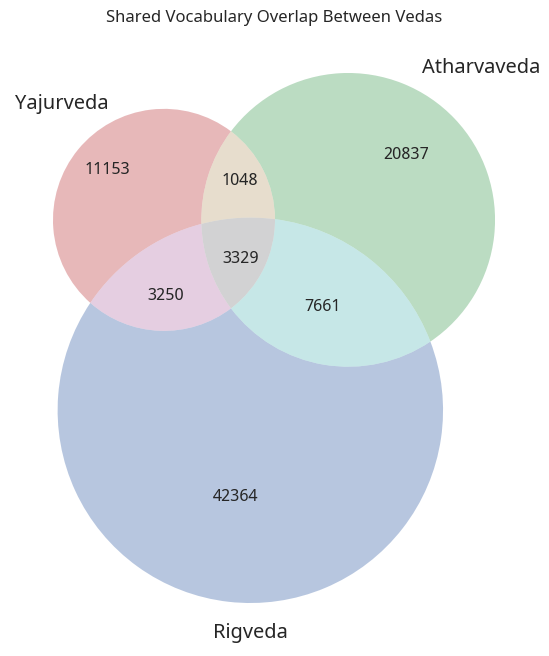

In [9]:
from matplotlib_venn import venn3

yv_vocab = set([word for word, count in yv_global.items() if count > 0])
av_vocab = set([word for word, count in av_global.items() if count > 0])
rv_vocab = set([word for word, count in rv_global.items() if count > 0])

if len(yv_vocab) > 0 and len(av_vocab) > 0 and len(rv_vocab) > 0:
    plt.figure(figsize=(10, 8))
    venn = venn3([yv_vocab, av_vocab, rv_vocab], ('Yajurveda', 'Atharvaveda', 'Rigveda'))
    # Formatting font for Devanagari labels if any
    for text in venn.set_labels:
        if text: text.set_fontfamily(plt.rcParams['font.family'])
    for text in venn.subset_labels:
        if text: text.set_fontfamily(plt.rcParams['font.family'])
    
    plt.title("Shared Vocabulary Overlap Between Vedas")
    plt.show()


## 9. Metrical / Phonetic Profile (Syllable Length)

Vedic texts are deeply rooted in their poetic meters (Chandas). We can perform a basic metrical profile by analyzing the distribution of word lengths (in syllables/vowels) across the different texts.


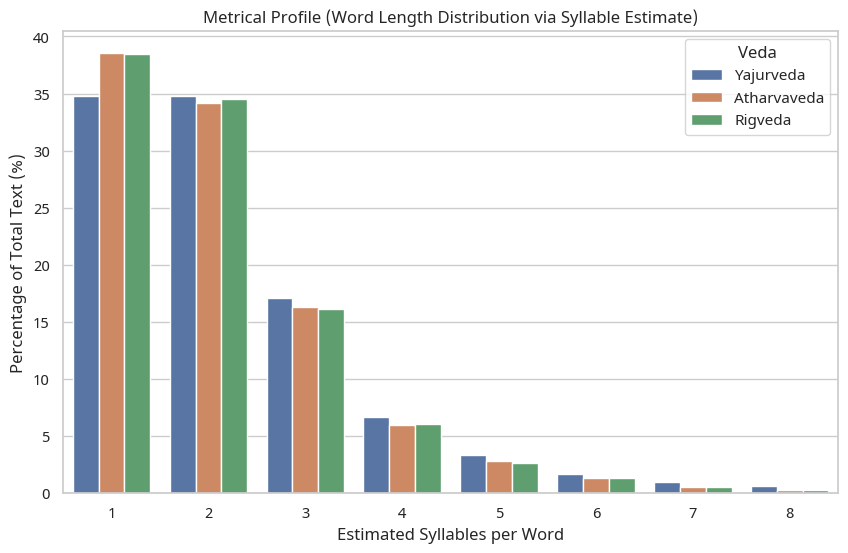

In [10]:
def count_syllables(word):
    # Basic heuristic: Count vowels (independent and dependent) in Devanagari
    # Also counting 'अ' inherent in consonants unless virama is present
    # This is a simplified approximation for general word length metrics
    vowels = r'[अआइईउऊऋॠऌएऐओऔािीुूृॄेैोौ]'
    consonants = r'[कखगघङचछजझञटठडढणतथदधनपफबभमयरलवशषसह]'
    virama = r'\u094D'
    
    explicit_vowels = len(re.findall(vowels, word))
    cons_count = len(re.findall(consonants, word))
    virama_count = len(re.findall(virama, word))
    
    # Inherent a = consonants - viramas - (dependent vowels ? roughly)
    # Just using explicit vowels + remaining consonants as a proxy for visual word length/syllables
    estimated_syllables = explicit_vowels + (cons_count - virama_count)
    return max(1, estimated_syllables // 2) # Div 2 as a very rough smoothing factor for sanskrit clusters

def get_syllable_distribution(global_freq):
    dist = Counter()
    for word, freq in global_freq.items():
        syl_count = count_syllables(word)
        if 0 < syl_count <= 8:  # Ignore extreme outliers/errors
            dist[syl_count] += freq
    return dist

yv_syl = get_syllable_distribution(yv_global)
av_syl = get_syllable_distribution(av_global)
rv_syl = get_syllable_distribution(rv_global)

syl_data = []
for veda_name, dist in [('Yajurveda', yv_syl), ('Atharvaveda', av_syl), ('Rigveda', rv_syl)]:
    total = sum(dist.values())
    if total == 0: continue
    for length, count in dist.items():
        syl_data.append({
            'Veda': veda_name,
            'Estimated Syllables per Word': length,
            'Percentage': (count / total) * 100
        })

if syl_data:
    import pandas as pd # Ensure pandas is imported if not globally available in cell
    import seaborn as sns
    syl_df = pd.DataFrame(syl_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=syl_df, x='Estimated Syllables per Word', y='Percentage', hue='Veda')
    plt.title("Metrical Profile (Word Length Distribution via Syllable Estimate)")
    plt.ylabel("Percentage of Total Text (%)")
    plt.show()


## 8. Comparative Vocabulary Overlap (Venn Diagram)

To understand the shared linguistic space across the Vedas, we can plot the intersection of their unique vocabularies.


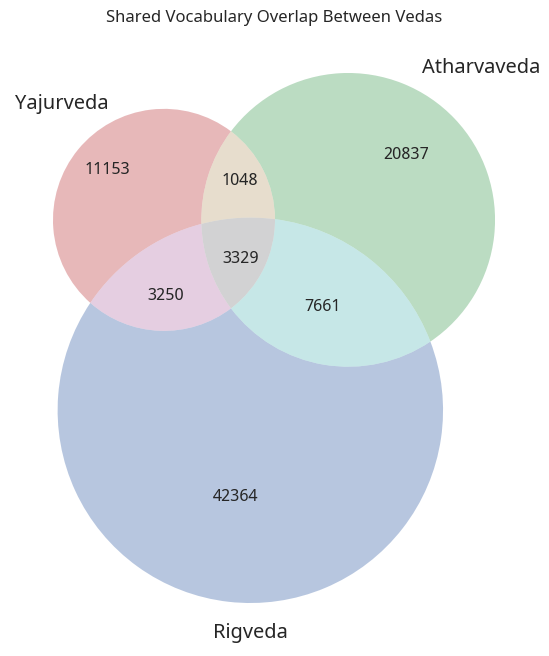

In [11]:
from matplotlib_venn import venn3

yv_vocab = set([word for word, count in yv_global.items() if count > 0])
av_vocab = set([word for word, count in av_global.items() if count > 0])
rv_vocab = set([word for word, count in rv_global.items() if count > 0])

if len(yv_vocab) > 0 and len(av_vocab) > 0 and len(rv_vocab) > 0:
    plt.figure(figsize=(10, 8))
    venn = venn3([yv_vocab, av_vocab, rv_vocab], ('Yajurveda', 'Atharvaveda', 'Rigveda'))
    # Formatting font for Devanagari labels if any
    for text in venn.set_labels:
        if text: text.set_fontfamily(plt.rcParams['font.family'])
    for text in venn.subset_labels:
        if text: text.set_fontfamily(plt.rcParams['font.family'])
    
    plt.title("Shared Vocabulary Overlap Between Vedas")
    plt.show()


## 9. Metrical / Phonetic Profile (Syllable Length)

Vedic texts are deeply rooted in their poetic meters (Chandas). We can perform a basic metrical profile by analyzing the distribution of word lengths (in syllables/vowels) across the different texts.


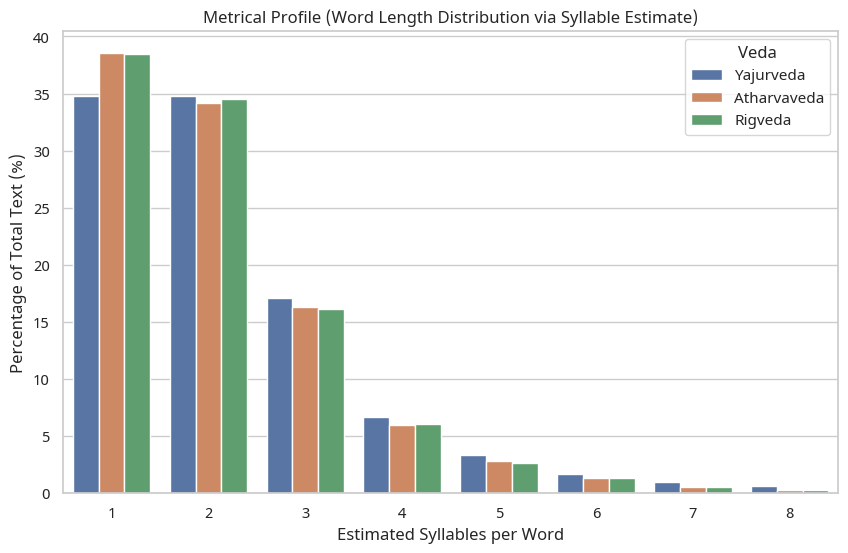

In [12]:
def count_syllables(word):
    # Basic heuristic: Count vowels (independent and dependent) in Devanagari
    # Also counting 'अ' inherent in consonants unless virama is present
    # This is a simplified approximation for general word length metrics
    vowels = r'[अआइईउऊऋॠऌएऐओऔािीुूृॄेैोौ]'
    consonants = r'[कखगघङचछजझञटठडढणतथदधनपफबभमयरलवशषसह]'
    virama = r'\u094D'
    
    explicit_vowels = len(re.findall(vowels, word))
    cons_count = len(re.findall(consonants, word))
    virama_count = len(re.findall(virama, word))
    
    # Inherent a = consonants - viramas - (dependent vowels ? roughly)
    # Just using explicit vowels + remaining consonants as a proxy for visual word length/syllables
    estimated_syllables = explicit_vowels + (cons_count - virama_count)
    return max(1, estimated_syllables // 2) # Div 2 as a very rough smoothing factor for sanskrit clusters

def get_syllable_distribution(global_freq):
    dist = Counter()
    for word, freq in global_freq.items():
        syl_count = count_syllables(word)
        if 0 < syl_count <= 8:  # Ignore extreme outliers/errors
            dist[syl_count] += freq
    return dist

yv_syl = get_syllable_distribution(yv_global)
av_syl = get_syllable_distribution(av_global)
rv_syl = get_syllable_distribution(rv_global)

syl_data = []
for veda_name, dist in [('Yajurveda', yv_syl), ('Atharvaveda', av_syl), ('Rigveda', rv_syl)]:
    total = sum(dist.values())
    if total == 0: continue
    for length, count in dist.items():
        syl_data.append({
            'Veda': veda_name,
            'Estimated Syllables per Word': length,
            'Percentage': (count / total) * 100
        })

if syl_data:
    import pandas as pd # Ensure pandas is imported if not globally available in cell
    import seaborn as sns
    syl_df = pd.DataFrame(syl_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=syl_df, x='Estimated Syllables per Word', y='Percentage', hue='Veda')
    plt.title("Metrical Profile (Word Length Distribution via Syllable Estimate)")
    plt.ylabel("Percentage of Total Text (%)")
    plt.show()
